<a href="https://colab.research.google.com/github/Kashyapdhar05/KashyapDhar_Deep_Learning-/blob/main/exp_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0834 - val_loss: 0.0063
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0112 - val_loss: 0.0020
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0076 - val_loss: 0.0019
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0070 - val_loss: 0.0020
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0063 - val_loss: 0.0028
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0048 - val_loss: 0.0018
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0049 - val_loss: 0.0017
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0

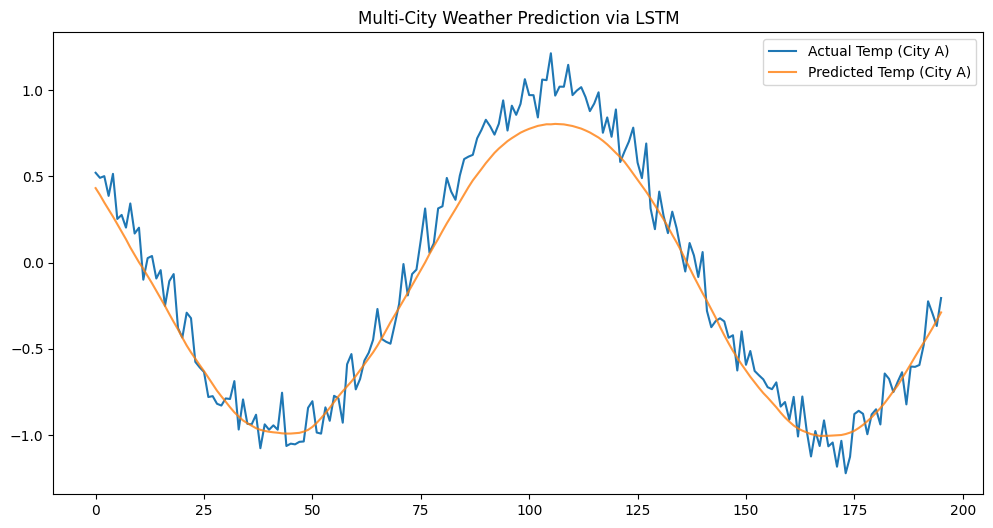

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. MOCK DATA GENERATION (Replace this with your CSV loading)
# Let's assume 3 cities, 2 features each (Temp, Press), 1000 hours of data
np.random.seed(42)
data_size = 1000
data = {
    'CityA_Temp': np.sin(np.linspace(0, 50, data_size)) + np.random.normal(0, 0.1, data_size),
    'CityA_Pres': np.cos(np.linspace(0, 50, data_size)) + np.random.normal(0, 0.1, data_size),
    'CityB_Temp': np.sin(np.linspace(0, 50, data_size) + 0.5) + np.random.normal(0, 0.1, data_size),
    'CityB_Pres': np.cos(np.linspace(0, 50, data_size) + 0.5) + np.random.normal(0, 0.1, data_size),
    'CityC_Temp': np.sin(np.linspace(0, 50, data_size) + 1.0) + np.random.normal(0, 0.1, data_size),
    'CityC_Pres': np.cos(np.linspace(0, 50, data_size) + 1.0) + np.random.normal(0, 0.1, data_size),
}
df = pd.DataFrame(data)

# 2. PREPROCESSING
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

def create_sequences(data, lookback, target_col_idx):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :]) # All city features
        y.append(data[i, target_col_idx]) # Target city's temperature
    return np.array(X), np.array(y)

# Use last 24 hours to predict the next hour
LOOKBACK = 24
TARGET_IDX = 0 # Predicting 'CityA_Temp'
X, y = create_sequences(scaled_data, LOOKBACK, TARGET_IDX)

# Split into Train and Test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. BUILDING THE LSTM MODEL
model = Sequential([
    # Input shape: (Time steps, Number of features)
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Final predicted temperature
])

model.compile(optimizer='adam', loss='mse')

# 4. TRAINING
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 5. EVALUATION & VISUALIZATION
predictions = model.predict(X_test)

# Inverse transform to get actual temperature values back
# Note: We create a dummy array to satisfy the scaler's shape requirement
dummy = np.zeros((len(predictions), scaled_data.shape[1]))
dummy[:, TARGET_IDX] = predictions.flatten()
inv_predictions = scaler.inverse_transform(dummy)[:, TARGET_IDX]

actual = np.zeros((len(y_test), scaled_data.shape[1]))
actual[:, TARGET_IDX] = y_test
inv_actual = scaler.inverse_transform(actual)[:, TARGET_IDX]

plt.figure(figsize=(12, 6))
plt.plot(inv_actual, label='Actual Temp (City A)')
plt.plot(inv_predictions, label='Predicted Temp (City A)', alpha=0.8)
plt.title('Multi-City Weather Prediction via LSTM')
plt.legend()
plt.show()